In [54]:
import torch
import torch.nn as nn

### Single Transformer block looks like this

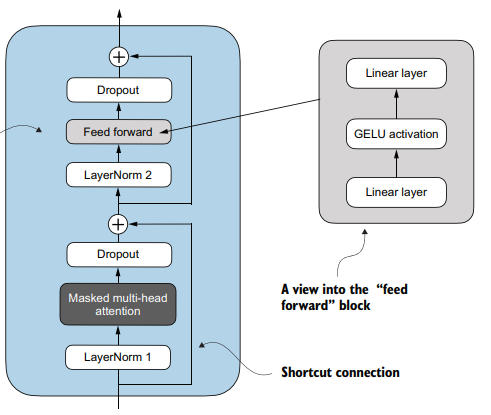

#### Overall GPT looks like this

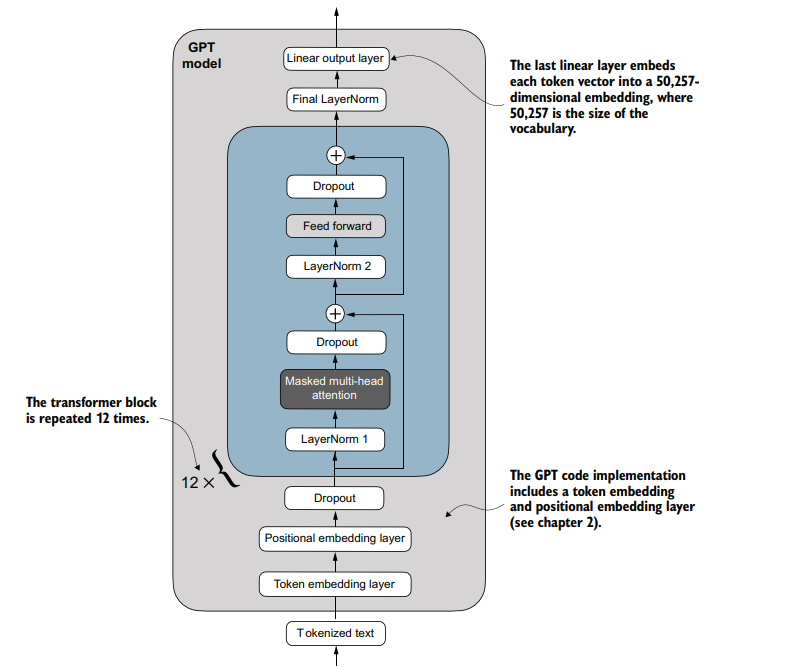

#### GPT configs

In [55]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
} 

In [ ]:
class LayerNormalization(torch.nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps=1e-5
        # emb_dim=torch.tensor(emb_dim,dtype=torch.float16)  commented cause torch.ones takes int as size 
        self.scale=torch.nn.Parameter(torch.ones(emb_dim))
        self.shift=torch.nn.Parameter(torch.zeros(emb_dim))
    def forward(self,x):
        self.mean=x.mean(dim=-1,keepdim=True)    
        self.var=x.var(dim=-1,keepdim=True,unbiased=False)
        norm=(x-self.mean)/torch.sqrt(self.var+self.eps)   
        out= norm*self.scale + self.shift 
        return out
    def get_norm_params(self):
        print(f"Means is {self.mean}, \n Variance is {self.var}")


In [57]:

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [58]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,n_heads,qkv_bias=False):
        super().__init__()
        assert (d_out % n_heads == 0), \
            "d_out must be divisible by num_heads"
        self.d_out=d_out
        self.n_heads=n_heads
        self.head_dim = d_out // n_heads

        self.W_q=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_k=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_v=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.dropout=nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length),
                       diagonal=1))
        self.out_proj = nn.Linear(d_out, d_out)  
        
    def forward(self,x):  
        b,num_token,d_in=x.shape 
        key=self.W_k(x)  
        query=self.W_q(x)
        value=self.W_v(x)

        key=key.view(b,num_token,self.n_heads,self.head_dim)
        query=query.view(b,num_token,self.n_heads,self.head_dim)
        value=value.view(b,num_token,self.n_heads,self.head_dim)

        key = key.transpose(1, 2)
        query = query.transpose(1, 2)
        value = value.transpose(1, 2)

        attn_scores = query @ key.transpose(2, 3)
        mask_bool = self.mask.bool()[:num_token, :num_token]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        attn_weights = torch.softmax(attn_scores / torch.sqrt(torch.tensor(self.head_dim)), dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vector= (attn_weights @ value).transpose(1, 2) 
        context_vector = context_vector.contiguous().view(b, num_token, self.d_out)
        context_vector=self.out_proj(context_vector)
        return context_vector


In [59]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layer=nn.Sequential(
            nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
            GELU(),
            nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"])
        )
    def forward(self,x):
        out=self.layer(x)
        return x    

In [ ]:
class Transformer(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.attn=MultiHeadAttention(
            d_in=GPT_CONFIG_124M["emb_dim"],
            d_out=GPT_CONFIG_124M["emb_dim"],
            context_length=GPT_CONFIG_124M["context_length"],
            dropout=GPT_CONFIG_124M["drop_rate"],
            n_heads=GPT_CONFIG_124M["n_heads"],
            qkv_bias=GPT_CONFIG_124M["qkv_bias"]
        )
        self.ff=FeedForward(cfg)
        self.norm1 = LayerNormalization(cfg["emb_dim"])
        self.norm2 = LayerNormalization(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
        
    def forward(self,x):

        shortcut = x
        x=self.norm1(x)
        x=self.attn(x)
        x=self.drop_shortcut(x)
        x=x+shortcut
         ## 2nd shortcut connection
        shortcut=x

        x=self.norm2(x)
        x=self.ff(x)
        x=self.drop_shortcut(x)
        x=x+shortcut
        return x
  
        
        

In [ ]:
x = torch.rand(2, 4, 768)
block = Transformer(GPT_CONFIG_124M)
output = block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])
